# 04 — Rate pass-through and refinancing scenarios

**Question.** A sovereign does not reprice its whole debt stock when market
yields move. Only the part that matures and is rolled over is repriced. So:

1. How far apart are the ten-year market yield and the effective rate actually
   paid on the outstanding stock?
2. How quickly does a change in the market yield show up in the effective rate?
3. Given that speed, what would a 50, 100, or 200 basis-point shock do to the
   interest burden, and over what horizon?

**Method note.** The pass-through estimates below come from about thirty annual
observations. They are descriptive summaries of a short sample, not identified
causal estimates, and the notebook reports the uncertainty rather than hiding
it. The scenarios are deterministic arithmetic — they are labelled that way in
the pipeline for a reason.

In [1]:
# Run correctly whether the kernel starts in notebooks/ or the repository root.
# Importing nbtools then puts src/ on the path, so pt_debt_interest is
# importable from a plain checkout without an editable install.
import sys
from pathlib import Path

_HERE = Path.cwd() if (Path.cwd() / "nbtools.py").is_file() else Path.cwd() / "notebooks"
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

import nbtools as nb
from pt_debt_interest.scenarios import (
    refinancing_pass_through,
    static_rate_shock_table,
)

nb.use_style()
ROOT = nb.repo_root()

df = nb.observed(nb.main_series(nb.load_dataset(ROOT)))
settings = nb.load_settings(ROOT)
rates = df.dropna(subset=["ten_year_yield_pct", "implicit_interest_rate_average_debt_pct"]).copy()

print(
    f"Paired rate observations: {len(rates)} "
    f"({int(rates['year'].min())}-{int(rates['year'].max())})"
)

Paired rate observations: 30 (1996-2025)


## 1. The market yield and the effective rate are different objects

Both are annual percentages, so they share one axis honestly. The market yield
is the price of *new* ten-year borrowing; the effective rate is what the
*existing* stock costs. The gap between them is the memory of past issuance.

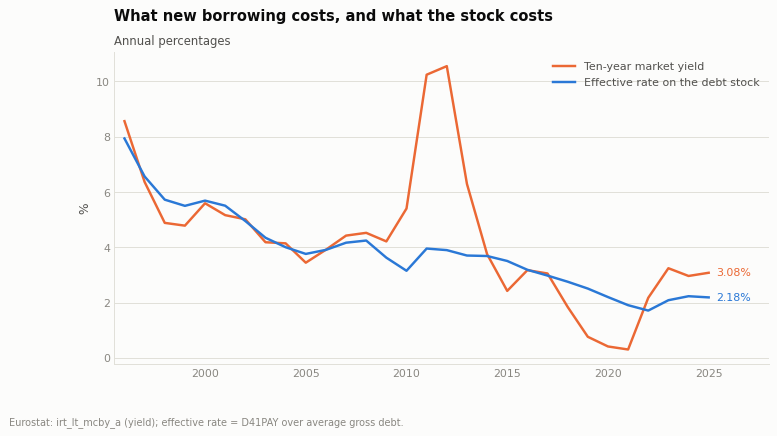

In [3]:
fig, ax = nb.figure(height=4.6)
ax.plot(
    rates["year"],
    rates["ten_year_yield_pct"],
    color=nb.SERIES[1],
    label="Ten-year market yield",
)
ax.plot(
    rates["year"],
    rates["implicit_interest_rate_average_debt_pct"],
    color=nb.SERIES[0],
    label="Effective rate on the debt stock",
)
for column, color in (
    ("ten_year_yield_pct", nb.SERIES[1]),
    ("implicit_interest_rate_average_debt_pct", nb.SERIES[0]),
):
    nb.label_last_point(ax, rates["year"], rates[column], "", color, fmt="{:.2f}%")
ax.set_xlim(rates["year"].min() - 0.5, rates["year"].max() + 3.0)
ax.legend(loc="upper right")
nb.finish(
    ax,
    title="What new borrowing costs, and what the stock costs",
    subtitle="Annual percentages",
    ylabel="%",
    source=("Eurostat: irt_lt_mcby_a (yield); effective rate = D41PAY over average gross debt."),
)
plt.show()

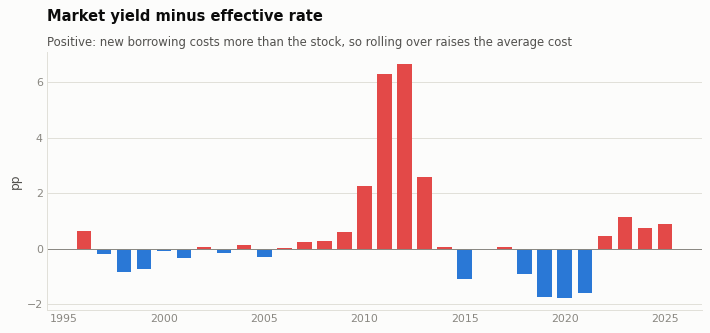

,value
years the market priced above the stock,17.00
years the market priced below the stock,13.00
mean spread (pp),0.44
latest spread (pp),0.89


In [4]:
rates["spread_pp"] = rates["ten_year_yield_pct"] - rates["implicit_interest_rate_average_debt_pct"]

fig, ax = nb.figure(height=3.8)
ax.bar(
    rates["year"],
    rates["spread_pp"],
    color=nb.signed_colors(rates["spread_pp"]),
    width=0.72,
)
ax.axhline(0, color=nb.MUTED, linewidth=0.8)
nb.finish(
    ax,
    title="Market yield minus effective rate",
    subtitle=(
        "Positive: new borrowing costs more than the stock, so rolling over raises the average cost"
    ),
    ylabel="pp",
    source="",
)
plt.show()

pd.Series(
    {
        "years the market priced above the stock": int((rates["spread_pp"] > 0).sum()),
        "years the market priced below the stock": int((rates["spread_pp"] < 0).sum()),
        "mean spread (pp)": round(rates["spread_pp"].mean(), 2),
        "latest spread (pp)": round(rates["spread_pp"].iloc[-1], 2),
    },
    name="value",
).to_frame()

## 2. How fast does a market move reach the stock?

If a constant share $s$ of the stock reprices each year, then a permanent change
in the market rate feeds into the effective rate at roughly $s$ per year, and
$1/s$ is the implied average residual maturity. Two independent readings follow.

### 2a. Correlation of annual changes at successive lags

Correlating the *change* in the effective rate with the *change* in the market
yield, lag by lag, shows where the response sits in time without imposing a
model. Confidence bands are the usual $\pm 2/\sqrt{n}$ rule of thumb.

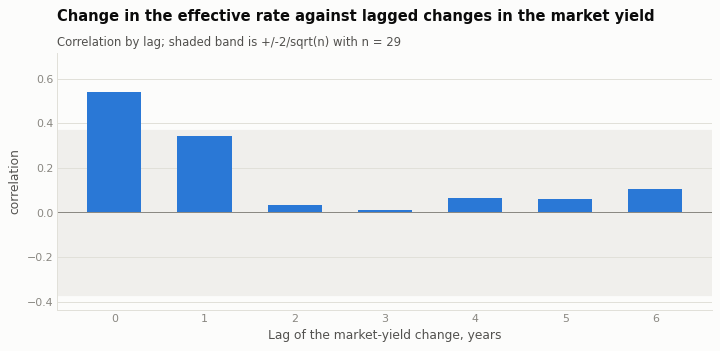

,correlation,observations
lag_years,,
0,0.54,29
1,0.35,28
2,0.04,27
3,0.01,26
4,0.06,25
5,0.06,24
6,0.11,23


In [5]:
changes = pd.DataFrame(
    {
        "year": rates["year"],
        "d_effective": rates["implicit_interest_rate_average_debt_pct"].diff(),
        "d_yield": rates["ten_year_yield_pct"].diff(),
    }
).dropna()

max_lag = 6
correlations = []
for lag in range(max_lag + 1):
    paired = pd.DataFrame(
        {"effective": changes["d_effective"], "yield": changes["d_yield"].shift(lag)}
    ).dropna()
    correlations.append(
        {
            "lag_years": lag,
            "correlation": paired["effective"].corr(paired["yield"]),
            "observations": len(paired),
        }
    )
correlation_table = pd.DataFrame(correlations).set_index("lag_years")
band = 2 / np.sqrt(len(changes))

fig, ax = nb.figure(height=3.8)
ax.bar(
    correlation_table.index,
    correlation_table["correlation"],
    color=nb.SERIES[0],
    width=0.6,
)
ax.axhspan(-band, band, color="#f0efec", zorder=0)
ax.axhline(0, color=nb.MUTED, linewidth=0.8, zorder=1)
ax.set_xticks(correlation_table.index)
nb.headroom(ax, top=1.22, bottom=1.05)
nb.finish(
    ax,
    title="Change in the effective rate against lagged changes in the market yield",
    subtitle=f"Correlation by lag; shaded band is +/-2/sqrt(n) with n = {len(changes)}",
    ylabel="correlation",
    xlabel="Lag of the market-yield change, years",
    source="",
)
plt.show()

correlation_table

### 2b. A distributed-lag regression

$$\Delta r_t = \alpha + \sum_{k=0}^{K} \beta_k \, \Delta y_{t-k} + \varepsilon_t$$

The sum of the $\beta_k$ is cumulative pass-through over $K+1$ years; $\beta_0$
is the share of the stock repriced within the first year. Standard errors are
Newey–West to allow for serial correlation. With this sample length the
coefficients are indicative, and the fit statistic below should be read as
"how much of the annual variation this tracks", not as validation.

In [6]:
lags = 3
design = pd.DataFrame({"d_effective": changes["d_effective"]})
for lag in range(lags + 1):
    design[f"d_yield_lag{lag}"] = changes["d_yield"].shift(lag)
design = design.dropna()

exog = sm.add_constant(design.drop(columns="d_effective"))
model = sm.OLS(design["d_effective"], exog).fit(cov_type="HAC", cov_kwds={"maxlags": 2})

coefficients = pd.DataFrame(
    {
        "coefficient": model.params,
        "std_error": model.bse,
        "t_stat": model.tvalues,
        "p_value": model.pvalues,
    }
)
print(f"Observations: {int(model.nobs)}   R-squared: {model.rsquared:.3f}")
coefficients

Observations: 26   R-squared: 0.303


,coefficient,std_error,t_stat,p_value
const,-0.11,0.06,-1.79,0.07
d_yield_lag0,0.11,0.03,3.43,0.00
d_yield_lag1,0.03,0.03,0.80,0.42
d_yield_lag2,0.01,0.04,0.38,0.70
d_yield_lag3,0.05,0.03,1.75,0.08


In [7]:
lag_terms = [name for name in model.params.index if name.startswith("d_yield_lag")]
cumulative = model.params[lag_terms].cumsum()
first_year_share = float(model.params["d_yield_lag0"])

summary = pd.DataFrame(
    {
        "horizon_years": range(1, len(lag_terms) + 1),
        "cumulative_pass_through": cumulative.to_numpy(),
    }
).set_index("horizon_years")
summary["share_of_a_full_move"] = summary["cumulative_pass_through"].map("{:.0%}".format)

configured_shares = list(settings.analysis.default_refinancing_shares)
if first_year_share > 0:
    implied_maturity = f"{1 / first_year_share:.1f} years"
else:
    implied_maturity = "not defined (beta_0 <= 0)"

print(f"First-year pass-through (beta_0)        : {first_year_share:.3f}")
print(f"Implied average residual maturity       : {implied_maturity}")
print(f"Configured first-year refinancing share : {configured_shares[0]:.3f}")
print(f"Implied by the configured share         : {1 / configured_shares[0]:.1f} years")
summary

First-year pass-through (beta_0)        : 0.110
Implied average residual maturity       : 9.1 years
Configured first-year refinancing share : 0.120
Implied by the configured share         : 8.3 years


,cumulative_pass_through,share_of_a_full_move
horizon_years,,
1,0.11,11%
2,0.14,14%
3,0.15,15%
4,0.20,20%


The regression's first-year coefficient and the refinancing share configured in
`config/default.yaml` are two routes to the same quantity — the fraction of the
stock that reprices within a year. Where they agree, the scenario assumptions
below are consistent with the observed history; where they differ, the gap is
the honest measure of how much the scenarios depend on an assumption rather than
on the data.

## 3. Static full-pass-through sensitivities

The simplest counterfactual: apply the shock to the *whole* stock. This is a
long-run arithmetic bound, not a one-year forecast, because the whole stock is
never refinanced at once. It comes straight from the project library so the
notebook and the generated report cannot disagree.

In [8]:
latest = df.iloc[-1]
shocks = list(settings.analysis.static_rate_shocks_bps)
static_table = static_rate_shock_table(float(latest["debt_pct_gdp"]), shocks)

static_table["burden_after_shock_pct_gdp"] = (
    latest["interest_pct_gdp"] + static_table["additional_interest_pct_gdp_full_pass_through"]
)
static_table["increase_vs_latest"] = (
    static_table["additional_interest_pct_gdp_full_pass_through"] / latest["interest_pct_gdp"]
).map("{:.0%}".format)

print(
    f"Baseline: {int(latest['year'])}, debt {latest['debt_pct_gdp']:.1f}% of GDP, "
    f"interest {latest['interest_pct_gdp']:.1f}% of GDP"
)
static_table.set_index("shock_bps")[
    [
        "additional_interest_pct_gdp_full_pass_through",
        "burden_after_shock_pct_gdp",
        "increase_vs_latest",
    ]
]

Baseline: 2025, debt 89.7% of GDP, interest 1.9% of GDP


,additional_interest_pct_gdp_full_pass_through,burden_after_shock_pct_gdp,increase_vs_latest
shock_bps,,,
50,0.45,2.35,24%
100,0.90,2.80,47%
200,1.79,3.69,94%


## 4. Gradual refinancing paths

The realistic version: the shock reaches only the share of the stock refinanced
each year, so the burden climbs towards the static bound over the maturity
profile. Refinancing shares come from `config/default.yaml`.

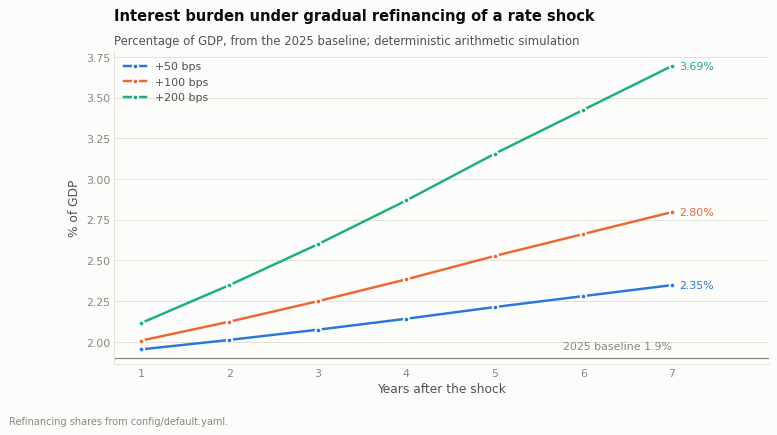

In [9]:
baseline_interest = float(latest["interest_pct_gdp"])
baseline_debt = float(latest["debt_pct_gdp"])

paths = pd.concat(
    [
        refinancing_pass_through(baseline_interest, baseline_debt, shock, configured_shares)
        for shock in shocks
    ],
    ignore_index=True,
)

fig, ax = nb.figure(height=4.6)
for position, shock in enumerate(shocks):
    path = paths.loc[paths["shock_bps"].eq(shock)]
    ax.plot(
        path["horizon_year"],
        path["interest_pct_gdp_scenario"],
        color=nb.SERIES[position],
        marker="o",
        markersize=4.5,
        markeredgecolor=nb.SURFACE,
        markeredgewidth=1.5,
        label=f"+{shock} bps",
    )
    nb.label_last_point(
        ax,
        path["horizon_year"],
        path["interest_pct_gdp_scenario"],
        "",
        nb.SERIES[position],
        fmt="{:.2f}%",
    )
ax.axhline(
    baseline_interest,
    color=nb.MUTED,
    linewidth=1.0,
    zorder=0,
)
ax.annotate(
    f"{int(latest['year'])} baseline {baseline_interest:.1f}%",
    xy=(max(paths["horizon_year"]), baseline_interest),
    xytext=(0, 7),
    textcoords="offset points",
    ha="right",
    fontsize=9,
    color=nb.MUTED,
)
ax.set_xticks(sorted(paths["horizon_year"].unique()))
ax.set_xlim(0.7, max(paths["horizon_year"]) + 1.1)
ax.legend(loc="upper left")
nb.finish(
    ax,
    title="Interest burden under gradual refinancing of a rate shock",
    subtitle=(
        f"Percentage of GDP, from the {int(latest['year'])} baseline; "
        "deterministic arithmetic simulation"
    ),
    ylabel="% of GDP",
    xlabel="Years after the shock",
    source="Refinancing shares from config/default.yaml.",
)
plt.show()

In [10]:
horizon = int(paths["horizon_year"].max())
comparison = paths.loc[paths["horizon_year"].eq(horizon)].set_index("shock_bps")[
    [
        "repriced_share_cumulative",
        "additional_interest_pct_gdp",
        "additional_interest_pct_gdp_full_pass_through",
        "gap_to_full_pass_through_pct_gdp",
        "pass_through_completion_pct",
    ]
]
print(f"After {horizon} years:")
comparison

After 7 years:


,repriced_share_cumulative,additional_interest_pct_gdp,additional_interest_pct_gdp_full_pass_through,gap_to_full_pass_through_pct_gdp,pass_through_completion_pct
shock_bps,,,,,
50,1.00,0.45,0.45,0.00,100.00
100,1.00,0.90,0.90,0.00,100.00
200,1.00,1.79,1.79,0.00,100.00


## 5. How much do the scenarios depend on the refinancing assumption?

The configured shares are an assumption, so the last thing to do is vary them.
A flat share $s$ per year is applied for the same horizon, spanning slower and
faster maturity profiles than the configured one.

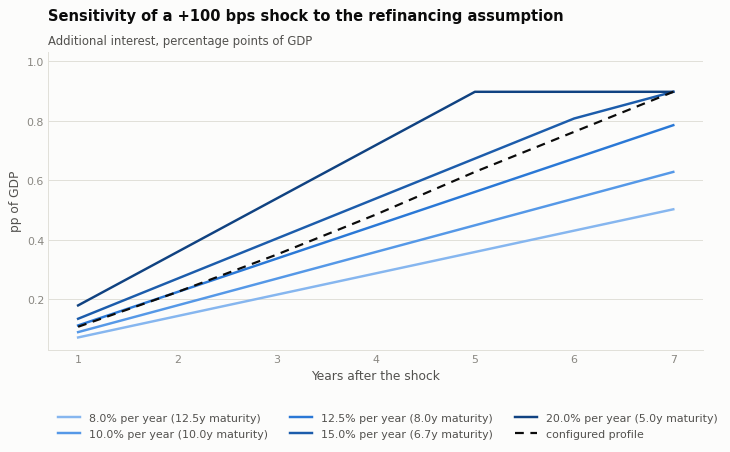

,repriced_share_cumulative,additional_interest_pct_gdp
annual_share,,
0.08,0.56,0.50
0.10,0.70,0.63
0.12,0.88,0.78
0.15,1.00,0.90
0.20,1.00,0.90


In [11]:
horizon_years = len(configured_shares)
flat_shares = [0.08, 0.10, 0.125, 0.15, 0.20]
shock_bps = 100


# Repeat a constant share, stopping once the whole stock has been repriced:
# the library rejects profiles that refinance more than the outstanding stock.
def flat_profile(share: float, years: int) -> list[float]:
    profile, remaining = [], 1.0
    for _ in range(years):
        step = min(share, remaining)
        profile.append(step)
        remaining -= step
    return profile


sensitivity = pd.concat(
    [
        refinancing_pass_through(
            baseline_interest,
            baseline_debt,
            shock_bps,
            flat_profile(share, horizon_years),
        ).assign(annual_share=share)
        for share in flat_shares
    ],
    ignore_index=True,
)

fig, ax = nb.figure(height=4.4)
for position, share in enumerate(flat_shares):
    path = sensitivity.loc[sensitivity["annual_share"].eq(share)]
    ax.plot(
        path["horizon_year"],
        path["additional_interest_pct_gdp"],
        color=nb.ORDINAL[position],
        label=f"{share:.1%} per year ({1 / share:.1f}y maturity)",
    )
configured_path = refinancing_pass_through(
    baseline_interest, baseline_debt, shock_bps, configured_shares
)
ax.plot(
    configured_path["horizon_year"],
    configured_path["additional_interest_pct_gdp"],
    color=nb.INK,
    linestyle=(0, (4, 3)),
    linewidth=1.8,
    label="configured profile",
)
ax.set_xticks(sorted(sensitivity["horizon_year"].unique()))
nb.headroom(ax, top=1.10)
ax.legend(loc="upper left", bbox_to_anchor=(0.0, -0.18), ncol=3)
nb.finish(
    ax,
    title=f"Sensitivity of a +{shock_bps} bps shock to the refinancing assumption",
    subtitle="Additional interest, percentage points of GDP",
    ylabel="pp of GDP",
    xlabel="Years after the shock",
    source="",
)
plt.show()

sensitivity.loc[sensitivity["horizon_year"].eq(horizon_years)].set_index("annual_share")[
    ["repriced_share_cumulative", "additional_interest_pct_gdp"]
]

## 6. Findings

In [12]:
best_lag = int(correlation_table["correlation"].idxmax())
static_100 = static_table.loc[
    static_table["shock_bps"].eq(100),
    "additional_interest_pct_gdp_full_pass_through",
].iloc[0]
gradual_100 = paths.loc[
    paths["shock_bps"].eq(100) & paths["horizon_year"].eq(horizon),
    "additional_interest_pct_gdp",
].iloc[0]

print(f"Latest spread (market minus effective) : {rates['spread_pp'].iloc[-1]:+.2f} pp")
print(f"Strongest correlation at lag           : {best_lag} year(s)")
print(f"First-year pass-through (beta_0)       : {first_year_share:.2f}")
print(
    f"Cumulative pass-through after {len(lag_terms)} years  : "
    f"{cumulative.iloc[-1]:.2f} of a full move"
)
print(
    f"+100 bps, long-run static bound        : {static_100:+.2f} pp of GDP "
    f"(burden {baseline_interest + static_100:.1f}%)"
)
print(
    f"+100 bps after {horizon} years of refinancing : {gradual_100:+.2f} pp of GDP "
    f"({gradual_100 / static_100:.0%} of the bound)"
)

Latest spread (market minus effective) : +0.89 pp
Strongest correlation at lag           : 0 year(s)
First-year pass-through (beta_0)       : 0.11
Cumulative pass-through after 4 years  : 0.20 of a full move
+100 bps, long-run static bound        : +0.90 pp of GDP (burden 2.8%)
+100 bps after 7 years of refinancing : +0.90 pp of GDP (100% of the bound)


**Reading.** The effective rate moves far less than the market yield in any one
year, which is the whole point of a long maturity profile: it converts a rate
shock into a slow, partial repricing. That cuts both ways. The 2011–2012 yield
spike never reached the stock in full, and neither did the near-zero yields of
2019–2021 — which is why the effective rate kept falling for years after market
rates had bottomed out, and why the post-2022 rise in market yields has so far
raised the effective rate only modestly.

**Caveats.** Thirty annual observations cannot separate the pass-through
mechanism from everything else that moved over the same period — programme
lending on non-market terms during the adjustment years is the obvious example,
since that debt was never priced at the market yield at all. The scenarios hold
the debt ratio, nominal GDP, and the maturity profile fixed and apply the shock
to a single baseline year; they are arithmetic, not forecasts.

**Next.** [05 — European comparison](05_european_comparison.ipynb) puts these
rates and burdens next to Portugal's peers.